In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("fifa_eda.csv")

In [3]:
df.isnull().sum()

ID                            0
Name                          0
Age                           0
Nationality                   0
Overall                       0
Potential                     0
Club                        241
Value                       252
Wage                          0
Preferred Foot                0
International Reputation     48
Skill Moves                  48
Position                      0
Joined                        0
Contract Valid Until        289
Height                        0
Weight                        0
Release Clause                0
dtype: int64

In [4]:
df = df.dropna()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17907 entries, 0 to 18206
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        17907 non-null  int64  
 1   Name                      17907 non-null  object 
 2   Age                       17907 non-null  int64  
 3   Nationality               17907 non-null  object 
 4   Overall                   17907 non-null  int64  
 5   Potential                 17907 non-null  int64  
 6   Club                      17907 non-null  object 
 7   Value                     17907 non-null  float64
 8   Wage                      17907 non-null  float64
 9   Preferred Foot            17907 non-null  object 
 10  International Reputation  17907 non-null  float64
 11  Skill Moves               17907 non-null  float64
 12  Position                  17907 non-null  object 
 13  Joined                    17907 non-null  int64  
 14  Contract Va

In [6]:
df.describe()

,ID,Age,Overall,Potential,Value,Wage,International Reputation,Skill Moves,Joined,Height,Weight,Release Clause
count,17907.000000,17907.000000,17907.000000,17907.000000,17907.000000,17907.000000,17907.000000,17907.000000,17907.000000,17907.000000,17907.000000,17907.000000
mean,214286.938795,25.095605,66.239571,71.335232,2450.132909,9.887753,1.113699,2.363042,2016.429553,5.946711,165.964316,4585.060974
std,29885.734201,4.660388,6.926818,6.137251,5633.206685,22.148656,0.395193,0.756256,2.027399,0.220812,15.602524,10719.096361
min,16.000000,16.000000,46.000000,48.000000,10.000000,1.000000,1.000000,1.000000,1991.000000,5.083333,110.000000,13.000000
25%,200257.500000,21.000000,62.000000,67.000000,325.000000,1.000000,1.000000,2.000000,2016.000000,5.750000,154.000000,563.000000
50%,221710.000000,25.000000,66.000000,71.000000,700.000000,3.000000,1.000000,2.000000,2017.000000,5.916667,165.000000,1300.000000
75%,236512.500000,28.000000,71.000000,75.000000,2100.000000,9.000000,1.000000,3.000000,2018.000000,6.083333,176.000000,4585.060806
max,246620.000000,45.000000,94.000000,95.000000,118500.000000,565.000000,5.000000,5.000000,2018.000000,6.750000,243.000000,228100.000000


In [7]:
data = [1,2,3,4,5]

# Step 1: Calculate the mean
mean = sum(data) / len(data)
print(mean) 

# Step 2: Calculate the variance (average of squared differences from the mean)
variance = sum([(x - mean) ** 2 for x in data]) / len(data)
print(variance)

# Step 3: Calculate the standard deviation (square root of the variance)
std_dev = variance ** 0.5
# or std_dev = math.sqrt(variance) after importing the math module
print(f"Manually calculated STD: {std_dev}")

3.0
2.0
Manually calculated STD: 1.4142135623730951


In [9]:
df = df[~df['Age'].between(36, 45)]

In [10]:
df.head(5)

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500.0,565.0,Left,5.0,4.0,RF,2004,2021-01-01,5.583333,159.0,226500.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000.0,405.0,Right,5.0,5.0,ST,2018,2022-01-01,6.166667,183.0,127100.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500.0,290.0,Right,5.0,5.0,LW,2017,2022-01-01,5.750000,150.0,228100.0
3,193080,De Gea,27,Spain,91,93,Manchester United,72000.0,260.0,Right,4.0,1.0,GK,2011,2020-01-01,6.333333,168.0,138600.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000.0,355.0,Right,4.0,4.0,RCM,2015,2023-01-01,5.916667,154.0,196400.0


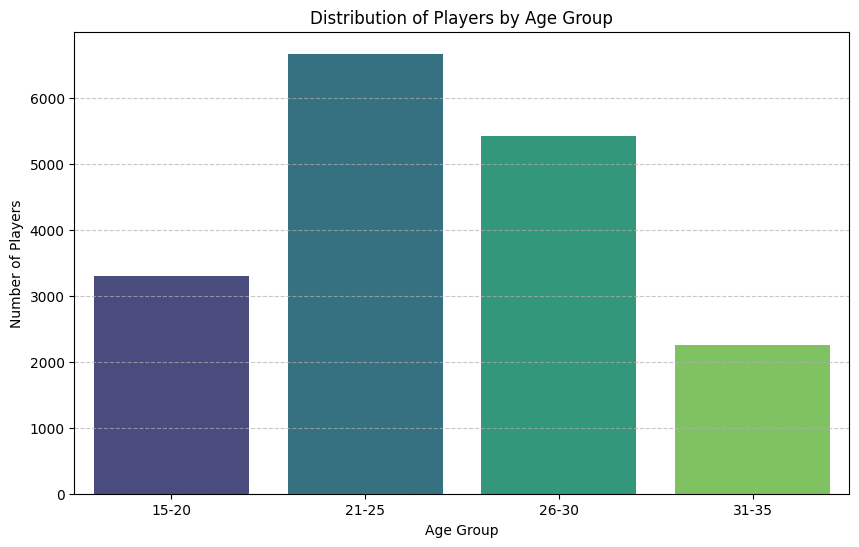

In [11]:
# Define age bins and labels
bins = [15, 20, 25, 30, 35]
labels = ['15-20', '21-25', '26-30', '31-35']

# Create 'AGE group' column
df['AGE group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Count players in each age group
age_group_counts = df['AGE group'].value_counts().sort_index()

# Plotting the bar graph
plt.figure(figsize=(10, 6))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, hue=age_group_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Players by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Players')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Correlation between Age and Potential: -0.25


<Figure size 300x300 with 0 Axes>

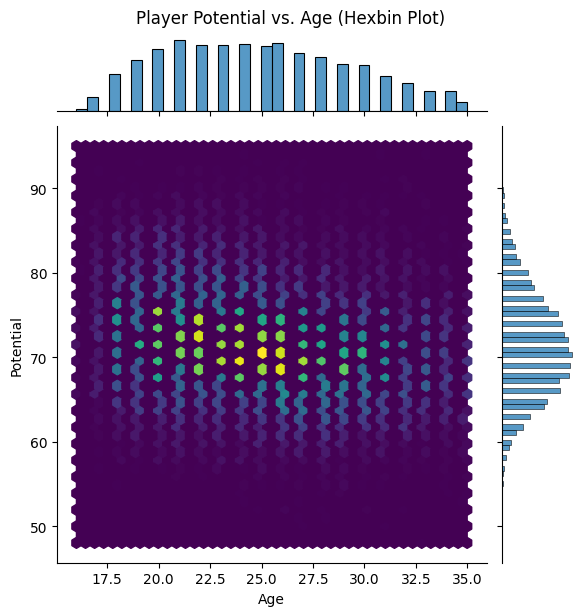

In [12]:
# Calculate the correlation between Age and Potential
correlation = df['Age'].corr(df['Potential'])
print(f"Correlation between Age and Potential: {correlation:.2f}")

# Create a hexbin plot to visualize the relationship and density
plt.figure(figsize=(3, 3))
sns.jointplot(x='Age', y='Potential', data=df, kind='hex', height=6, cmap='viridis')
plt.suptitle('Player Potential vs. Age (Hexbin Plot)', y=1.02) # Adjust suptitle position
plt.xlabel('Age') # These labels might be overridden by jointplot's internal labeling
plt.ylabel('Potential') # These labels might be overridden by jointplot's internal labeling
plt.show()

Correlation between Age and Potential: -0.25
Correlation between Weight and Potential: -0.00
Correlation between Age and Weight: 0.22


C:\Users\Admin\AppData\Local\Temp\ipykernel_5928\3051708634.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_potential_by_age_weight = df.groupby(['Age', 'Weight_Category'])['Potential'].mean().reset_index()


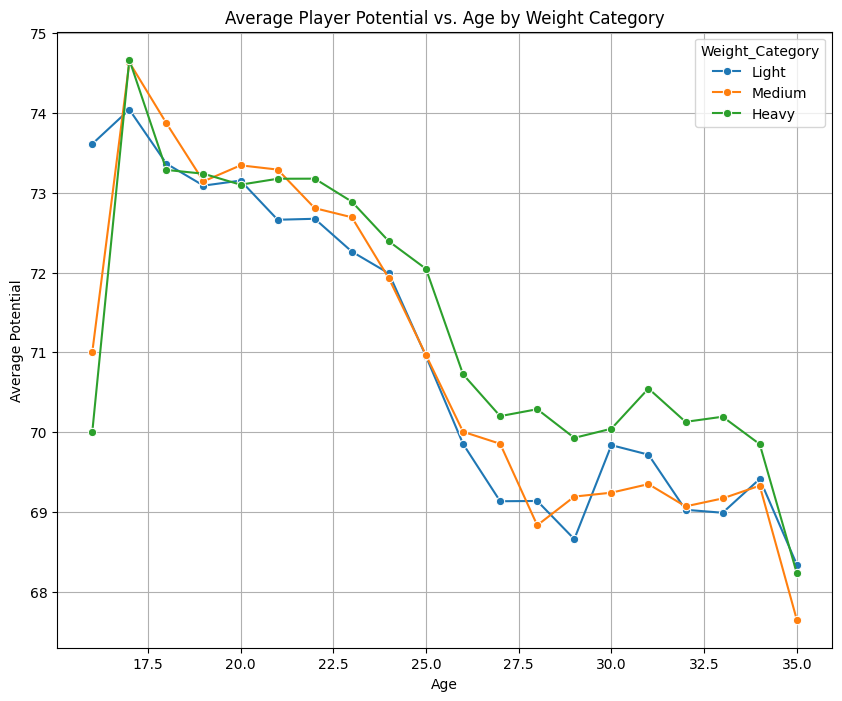

In [13]:
# Calculate correlations between Age, Weight, and Potential
correlation_age_potential = df['Age'].corr(df['Potential'])
correlation_weight_potential = df['Weight'].corr(df['Potential'])
correlation_age_weight = df['Age'].corr(df['Weight'])

print(f"Correlation between Age and Potential: {correlation_age_potential:.2f}")
print(f"Correlation between Weight and Potential: {correlation_weight_potential:.2f}")
print(f"Correlation between Age and Weight: {correlation_age_weight:.2f}")

# Create weight bins for clearer visualization
df['Weight_Category'] = pd.qcut(df['Weight'], q=3, labels=['Light', 'Medium', 'Heavy'], duplicates='drop')

# Calculate the mean potential for each age and weight category
average_potential_by_age_weight = df.groupby(['Age', 'Weight_Category'])['Potential'].mean().reset_index()

# Create a line plot of average Potential vs. Age, with lines for each Weight Category
plt.figure(figsize=(10, 8))
sns.lineplot(x='Age', y='Potential', hue='Weight_Category', data=average_potential_by_age_weight, marker='o')
plt.title('Average Player Potential vs. Age by Weight Category')
plt.xlabel('Age')
plt.ylabel('Average Potential')
plt.grid(True)
plt.show()

'Correlation Matrix of all DataFrame columns:'

,ID,Age,Overall,Potential,Value,Wage,International Reputation,Skill Moves,Joined,Height,Weight,Release Clause
ID,1.000000,-0.734450,-0.455429,0.029704,-0.173489,-0.238396,-0.351686,-0.092023,0.202453,-0.086342,-0.186038,-0.154317
Age,-0.734450,1.000000,0.473195,-0.245308,0.097627,0.160638,0.243935,0.057113,-0.180708,0.077585,0.221790,0.077373
Overall,-0.455429,0.473195,1.000000,0.660378,0.636172,0.577727,0.501247,0.422603,-0.175997,0.038011,0.154379,0.605648
Potential,0.029704,-0.245308,0.660378,1.000000,0.581219,0.489095,0.379016,0.353809,-0.060751,-0.008132,-0.003151,0.568266
Value,-0.173489,0.097627,0.636172,0.581219,1.000000,0.859028,0.674054,0.317167,-0.126660,0.004048,0.050199,0.973445
Wage,-0.238396,0.160638,0.577727,0.489095,0.859028,1.000000,0.685059,0.266156,-0.153469,0.019839,0.067053,0.830308
International Reputation,-0.351686,0.243935,0.501247,0.379016,0.674054,0.685059,1.000000,0.216043,-0.132705,0.031879,0.082777,0.640710
Skill Moves,-0.092023,0.057113,0.422603,0.353809,0.317167,0.266156,0.216043,1.000000,0.011250,-0.418439,-0.344430,0.299361
Joined,0.202453,-0.180708,-0.175997,-0.060751,-0.126660,-0.153469,-0.132705,0.011250,1.000000,0.000595,-0.025500,-0.126180
Height,-0.086342,0.077585,0.038011,-0.008132,0.004048,0.019839,0.031879,-0.418439,0.000595,1.000000,0.755091,0.003050


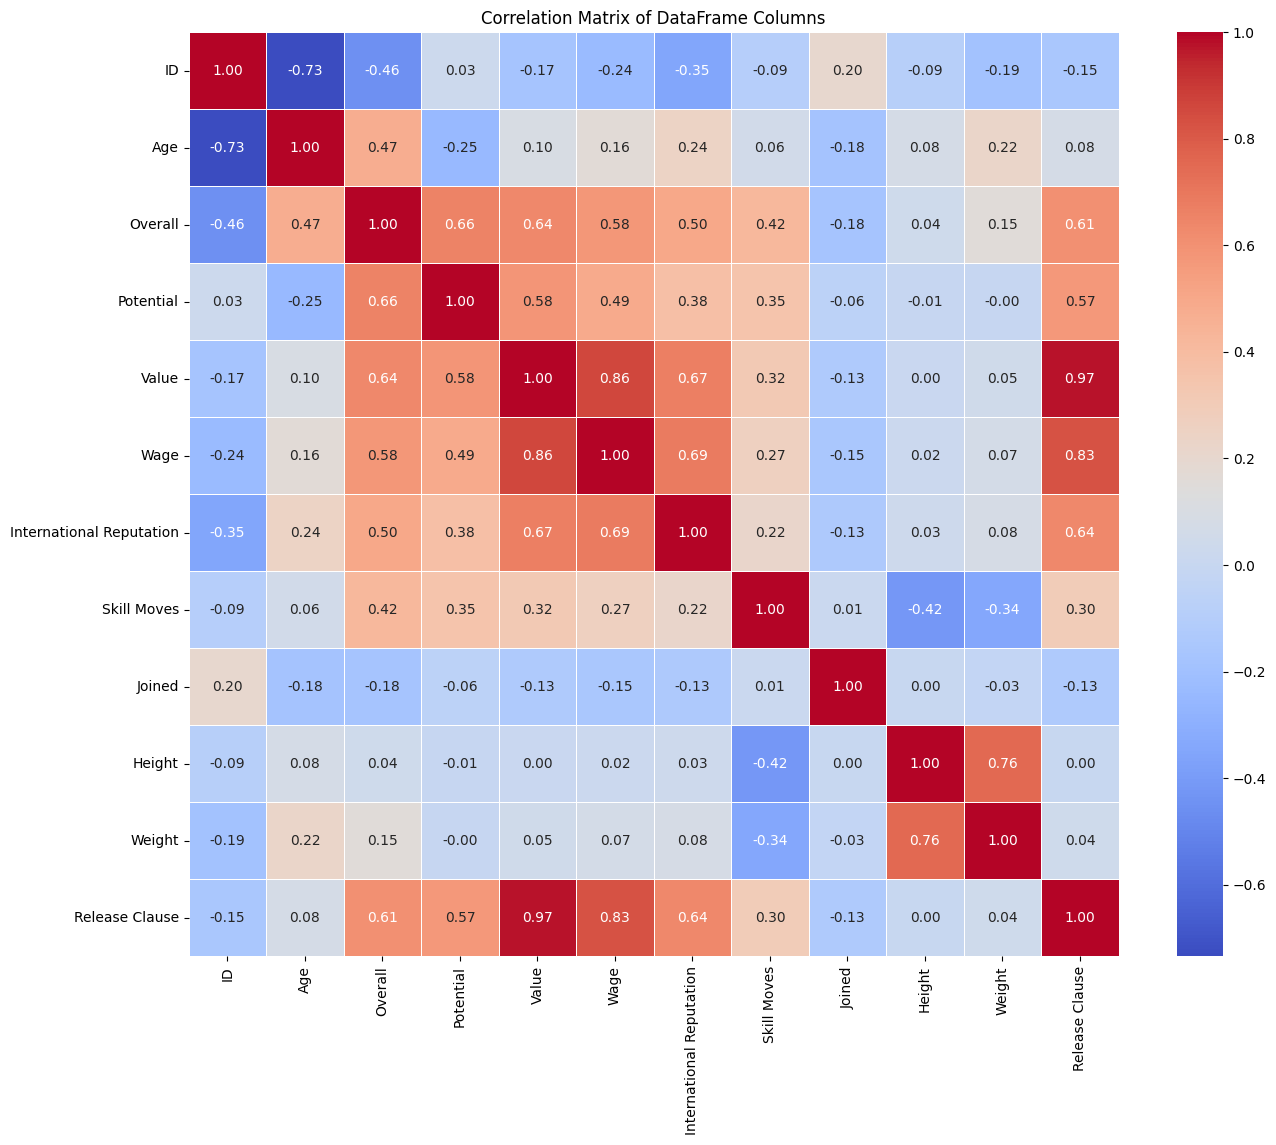

In [14]:
# Calculate the correlation matrix for all numerical columns in the DataFrame
correlation_matrix = df.corr(numeric_only=True)

display("Correlation Matrix of all DataFrame columns:", correlation_matrix)

# Optionally, visualize the correlation matrix using a heatmap for better readability
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of DataFrame Columns')
plt.show()